## EXERCICE NUMBER 1 ##

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

In [2]:
def f(x):
    return np.cos(2 * np.pi * x**2)

In [6]:
I_exact, _ = integrate.quad(f, 0, 1 , limit = 100)
print(f"Valeur exacte de l'intégrale : {I_exact:.10f}")


Valeur exacte de l'intégrale : 0.2441267030


In [8]:
def monte_carlo_estimate(N):
    U = np.random.uniform(0, 1, N)
    f_values = f(U)
    I_est = np.mean(f_values)
    return I_est

In [10]:
N_values = [100, 10000, 1000000]
estimations = []

print("Estimation de Monte Carlo:")
print("-" * 60)
for N in N_values:
    I_est = monte_carlo_estimate(N)
    erreur_abs = abs(I_est - I_exact)
    estimations.append((N, I_est,  erreur_abs))
    
    print(f"N = {N:8,d}")
    print(f"  Estimation : {I_est:.10f}")
    print(f"  Erreur absolue : {erreur_abs:.10f}")
    

Estimation de Monte Carlo:
------------------------------------------------------------
N =      100
  Estimation : 0.3878105388
  Erreur absolue : 0.1436838358
N =   10,000
  Estimation : 0.2423964487
  Erreur absolue : 0.0017302543
N = 1,000,000
  Estimation : 0.2440236320
  Erreur absolue : 0.0001030710


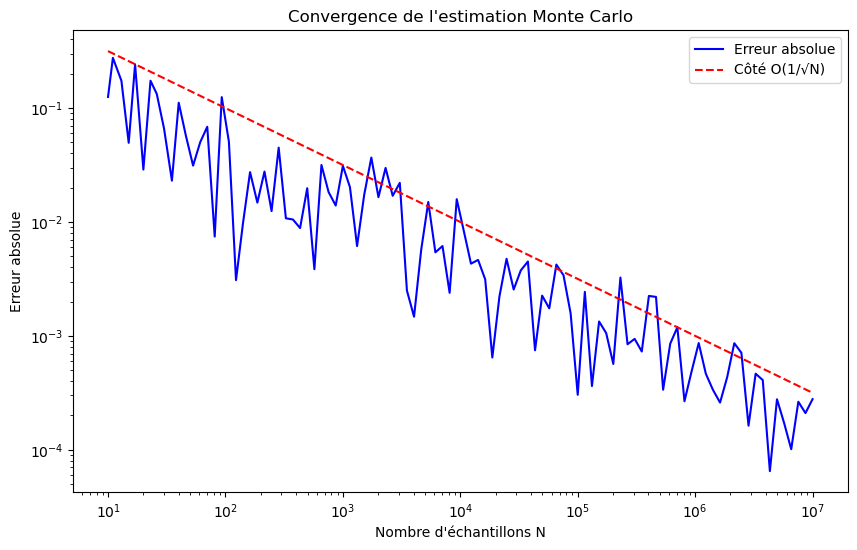

In [13]:
np.random.seed(42) 
N_test = np.logspace(1, 7, 100).astype(int)
errors = []
estimates = []

for N in N_test:
    I_est = monte_carlo_estimate(N)
    estimates.append(I_est)
    errors.append(abs(I_est - I_exact))

plt.figure(figsize=(10, 6))
plt.loglog(N_test, errors, label='Erreur absolue', color='blue')
plt.loglog(N_test, 1/np.sqrt(N_test), label='Côté O(1/√N)', color='red', linestyle='--')
plt.xlabel('Nombre d\'échantillons N')
plt.ylabel('Erreur absolue')
plt.title('Convergence de l\'estimation Monte Carlo')
plt.legend()
plt.show()

## EXERCISE NUMBER 2 ##

In [28]:
Σ = np.array([[1, 0.8],[0.8, 1]])
L = np.linalg.cholesky(Σ)
np.random.seed(42) 
n_samples = 10000
Z = np.random.randn(2, n_samples)
X = L @ Z
corr_matrix = np.corrcoef(X)

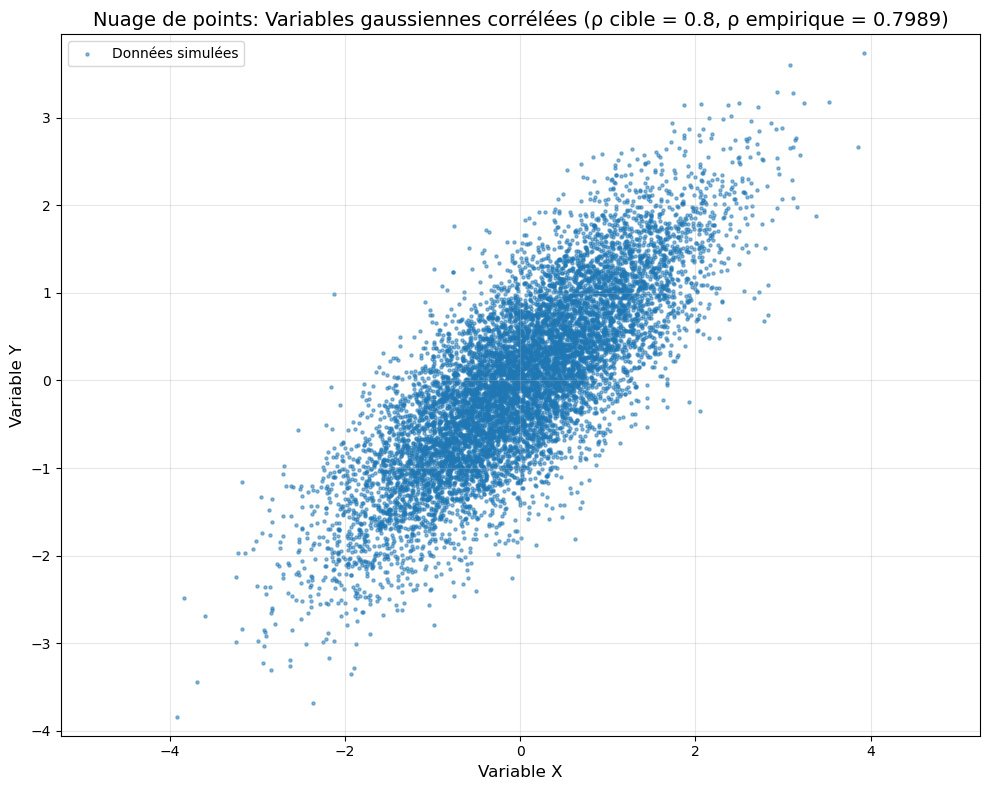

In [26]:
plt.figure(figsize=(10, 8))
plt.scatter(X[0], X[1], alpha=0.5, s=5, label='Données simulées')
plt.xlabel('Variable X', fontsize=12)
plt.ylabel('Variable Y', fontsize=12)
plt.title(f'Nuage de points: Variables gaussiennes corrélées (ρ cible = 0.8, ρ empirique = {corr_matrix[0,1]:.4f})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

## EXERCISE NUMBER 3 ##

Données originales: [ 12  15  12  14  35  13  16  11  14  15  12  19 105  14  13]
Médiane originale : 14.0
Bootstarps medians : [14. 14. 14. ... 14. 14. 14.]


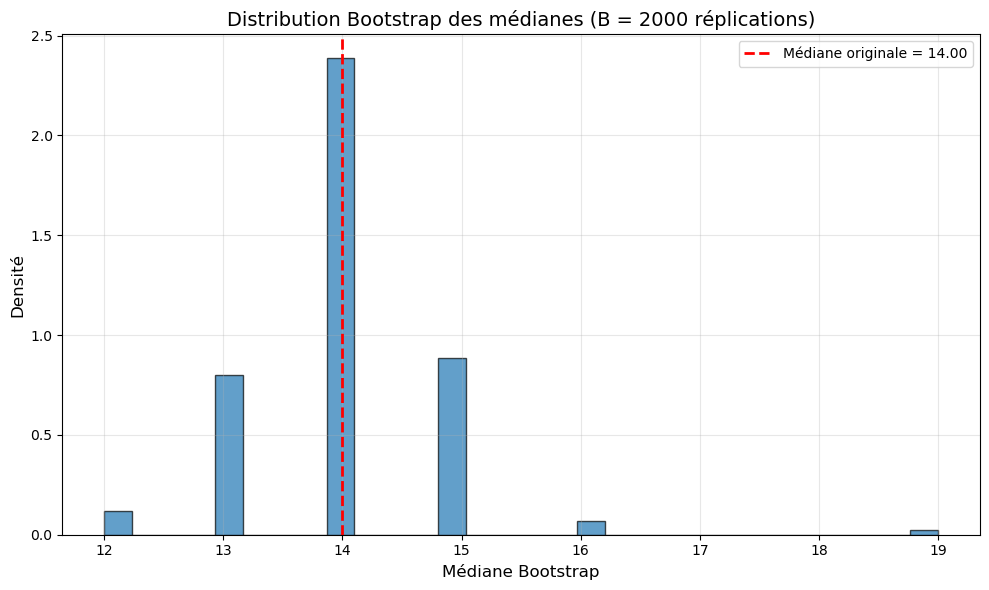

   Intervalle de confiance à 95%: [12.0000, 15.0000]


In [ ]:
Data = np.array([12, 15, 12, 14, 35, 13, 16, 11, 14, 15, 12, 19, 105, 14, 13])
print("Données originales:", Data)
median_original = np.median(Data)
print("Médiane originale :", median_original)
np.random.seed(42) 
B = 2000
n = len(Data)
bootstrap_samples = []

for i in range(B):
    sample = np.random.choice(Data, size=n, replace=True)
    bootstrap_samples.append(sample)

bootstrap_samples = np.array(bootstrap_samples)
bootstrap_medians = np.median(bootstrap_samples, axis=1)
print( "Bootstarps medians :"  , bootstrap_medians)


plt.figure(figsize=(10, 6))
plt.hist(bootstrap_medians, bins=30, edgecolor='black', alpha=0.7, density=True)
plt.axvline(x=median_original, color='red', linestyle='--', linewidth=2, label=f'Médiane originale = {median_original:.2f}')
plt.xlabel('Médiane Bootstrap', fontsize=12)
plt.ylabel('Densité', fontsize=12)
plt.title(f'Distribution Bootstrap des médianes (B = {B} réplications)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

alpha = 0.05
ci_lower = np.percentile(bootstrap_medians, 2.5)
ci_upper = np.percentile(bootstrap_medians, 97.5)
print(f"   Intervalle de confiance à 95%: [{ci_lower:.4f}, {ci_upper:.4f}]")